## Face Detection and Counting Pipeline
This notebook implements an end-to-end pipeline to count the number of faces in an image.

Approach A: Train a custom face detector using the WIDER FACE for YOLO dataset.

Approach B: Run zero-shot inference using a pre-trained RetinaFace model for complex/crowded scenes.

In [3]:
%%capture
# Cell 2: Install dependencies quietly and hide background environment conflicts
!pip install retina-face ultralytics kagglehub

# Dataset Acquisition via KaggleHub

In [2]:
import kagglehub
import os

# Download latest version of the dataset
dataset_path = kagglehub.dataset_download("iamprateek/wider-face-a-face-detection-dataset")

print("=========================================")
print("✅ Dataset downloaded and cached successfully!")
print("Path to dataset files:", dataset_path)
print("=========================================")

print("Directory contents:", os.listdir(dataset_path))

✅ Dataset downloaded and cached successfully!
Path to dataset files: /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset
Directory contents: ['WIDER_test', 'wider_face_annotations', 'WIDER_train', 'WIDER_val']


# Writable YOLO Directory Design

In [4]:
import os
import shutil

# Base input folder from kagglehub
WIDER_BASE_DIR = dataset_path

# Target output directories for YOLO training format (must be inside /kaggle/working/)
YOLO_BASE_DIR = "/kaggle/working/yolo_face_data"
YOLO_TRAIN_IMG_DIR = os.path.join(YOLO_BASE_DIR, "images/train")
YOLO_VAL_IMG_DIR = os.path.join(YOLO_BASE_DIR, "images/val")
YOLO_TRAIN_LABEL_DIR = os.path.join(YOLO_BASE_DIR, "labels/train")
YOLO_VAL_LABEL_DIR = os.path.join(YOLO_BASE_DIR, "labels/val")

# Generate the directory tree
os.makedirs(YOLO_TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_VAL_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_TRAIN_LABEL_DIR, exist_ok=True)
os.makedirs(YOLO_VAL_LABEL_DIR, exist_ok=True)

print("📁 Writable YOLO data structure configured at:", YOLO_BASE_DIR)

📁 Writable YOLO data structure configured at: /kaggle/working/yolo_face_data


## Robust WIDER FACE to YOLO Parsing Pipeline

In [5]:
import os
import shutil
import cv2

# Base input folder from kagglehub
WIDER_BASE_DIR = dataset_path

# Target output directories for YOLO training format (inside /kaggle/working/)
YOLO_BASE_DIR = "/kaggle/working/yolo_face_data"
YOLO_TRAIN_IMG_DIR = os.path.join(YOLO_BASE_DIR, "images/train")
YOLO_VAL_IMG_DIR = os.path.join(YOLO_BASE_DIR, "images/val")
YOLO_TRAIN_LABEL_DIR = os.path.join(YOLO_BASE_DIR, "labels/train")
YOLO_VAL_LABEL_DIR = os.path.join(YOLO_BASE_DIR, "labels/val")

# Generate the directory tree
os.makedirs(YOLO_TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_VAL_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_TRAIN_LABEL_DIR, exist_ok=True)
os.makedirs(YOLO_VAL_LABEL_DIR, exist_ok=True)

# 🛠️ HELPER FUNCTIONS: Scan the folder structure dynamically to prevent path errors
def find_file_globally(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in files:
            return os.path.join(root, target_name)
    return None

def find_images_dir_globally(base_dir, split_keyword):
    for root, dirs, files in os.walk(base_dir):
        if root.endswith("images") and split_keyword in root:
            return root
    return None

# Locate files dynamically across any nested subfolders
print("🔄 Scanning Kaggle dataset structure for paths...")
train_annot = find_file_globally(WIDER_BASE_DIR, "wider_face_train_bbx_gt.txt")
val_annot = find_file_globally(WIDER_BASE_DIR, "wider_face_val_bbx_gt.txt")
train_src_dir = find_images_dir_globally(WIDER_BASE_DIR, "WIDER_train")
val_src_dir = find_images_dir_globally(WIDER_BASE_DIR, "WIDER_val")

print("\n🔍 Dynamic Path Discovery Results:")
print(f"  -> Found Train Annotations: {train_annot}")
print(f"  -> Found Val Annotations:   {val_annot}")
print(f"  -> Found Train Images Dir:  {train_src_dir}")
print(f"  -> Found Val Images Dir:    {val_src_dir}\n")

# Robust parser function with self-alignment logic
def convert_wider_face_to_yolo(annotation_file, src_img_dir, dst_img_dir, dst_label_dir):
    if not annotation_file or not os.path.exists(annotation_file):
        print(f"❌ Error: Target annotation file path is missing or invalid.")
        return
    if not src_img_dir or not os.path.exists(src_img_dir):
        print(f"❌ Error: Source images directory path is missing or invalid.")
        return
        
    # Read and strip out all blank lines entirely
    with open(annotation_file, 'r') as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    i = 0
    count_processed = 0
    
    while i < len(lines):
        current_line = lines[i]
        
        # Self-healing validation step: ensure this line looks like an image format path
        if not (current_line.lower().endswith('.jpg') or current_line.lower().endswith('.png') or current_line.lower().endswith('.jpeg')):
            i += 1
            continue
            
        img_rel_path = current_line
        
        if i + 1 >= len(lines):
            break
            
        try:
            num_boxes = int(lines[i+1])
        except ValueError:
            # If next line isn't an integer, structural misalignment happened; skip ahead safely
            i += 1
            continue
            
        bboxes = []
        box_line_start = i + 2
        
        # FIX HERE: If num_boxes is 0, WIDER FACE still leaves a 1-row placeholder line of zeros.
        # We read 1 line anyway to clear it out, but don't add it to bounding boxes.
        lines_to_consume = num_boxes if num_boxes > 0 else 1
        
        for j in range(lines_to_consume):
            if box_line_start + j < len(lines):
                box_line = lines[box_line_start + j]
                
                # Double-check we didn't run over into a new image path accidentally
                if box_line.lower().endswith('.jpg') or box_line.lower().endswith('.png') or box_line.lower().endswith('.jpeg'):
                    lines_to_consume = j
                    break
                
                if num_boxes > 0: # Only process valid faces
                    parts = box_line.split()
                    if len(parts) >= 4:
                        try:
                            x1 = float(parts[0])
                            y1 = float(parts[1])
                            w = float(parts[2])
                            h = float(parts[3])
                            bboxes.append([x1, y1, w, h])
                        except ValueError:
                            pass
                            
        # Safely increment index past the filename, box count, and parsed lines
        i = box_line_start + lines_to_consume
        
        # Save images and label records only if faces are present
        src_img_path = os.path.join(src_img_dir, img_rel_path)
        if os.path.exists(src_img_path) and len(bboxes) > 0:
            img = cv2.imread(src_img_path)
            if img is not None:
                h_img, w_img, _ = img.shape
                
                flat_img_name = img_rel_path.replace('/', '_')
                dst_img_path = os.path.join(dst_img_dir, flat_img_name)
                
                shutil.copy(src_img_path, dst_img_path)
                
                label_name = os.path.splitext(flat_img_name)[0] + ".txt"
                dst_label_path = os.path.join(dst_label_dir, label_name)
                
                with open(dst_label_path, 'w') as lf:
                    for box in bboxes:
                        x1, y1, w, h = box
                        if w <= 0 or h <= 0:
                            continue
                        x_center = (x1 + w / 2.0) / w_img
                        y_center = (y1 + h / 2.0) / h_img
                        w_norm = w / w_img
                        h_norm = h / h_img
                        
                        lf.write(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")
                
                count_processed += 1

    print(f"✨ Successfully parsed and copied {count_processed} images.")

# --- Run Pipeline Execution ---
if train_annot and train_src_dir:
    print("🔄 Processing Training Split...")
    convert_wider_face_to_yolo(train_annot, train_src_dir, YOLO_TRAIN_IMG_DIR, YOLO_TRAIN_LABEL_DIR)
else:
    print("❌ Preprocessing stopped: Training pathways could not be mapped.")

if val_annot and val_src_dir:
    print("\n🔄 Processing Validation Split...")
    convert_wider_face_to_yolo(val_annot, val_src_dir, YOLO_VAL_IMG_DIR, YOLO_VAL_LABEL_DIR)
else:
    print("❌ Preprocessing stopped: Validation pathways could not be mapped.")

🔄 Scanning Kaggle dataset structure for paths...

🔍 Dynamic Path Discovery Results:
  -> Found Train Annotations: /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt
  -> Found Val Annotations:   /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt
  -> Found Train Images Dir:  /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images
  -> Found Val Images Dir:    /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images

🔄 Processing Training Split...
✨ Successfully parsed and copied 12876 images.

🔄 Processing Validation Split...
✨ Successfully parsed and copied 3226 images.


## 7. Create data.yaml Configuration

In [6]:
import yaml

# Design configuration schema for YOLOv8/YOLOv11
data_yaml = {
    'train': YOLO_TRAIN_IMG_DIR,
    'val': YOLO_VAL_IMG_DIR,
    'nc': 1,
    'names': ['face']
}

yaml_path = os.path.join(YOLO_BASE_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"📝 data.yaml dynamically created at: {yaml_path}")

📝 data.yaml dynamically created at: /kaggle/working/yolo_face_data/data.yaml


## Execute YOLO Training

In [7]:
from ultralytics import YOLO

# Load pre-trained basic weights
model = YOLO('yolov8n.pt') 

# Train model 
results = model.train(
    data=yaml_path,
    epochs=70,             # Swap out or increase as needed
    imgsz=640,
    batch=16,
    device=0,              # Uses Kaggle default primary GPU mapping
    project='/kaggle/working/runs',
    name='face_detection'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_face_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_

AttributeError: module 'numpy' has no attribute '_no_nep50_warning'

In [8]:
import numpy as np

# Create a dummy decorator to bypass the SciPy version mismatch bug
def dummy_npwarn_decorator_factory():
    def npwarn_decorator(x):
        return x
    return npwarn_decorator

# Inject the dummy placeholder directly into the live NumPy environment
np._no_nep50_warning = getattr(np, '_no_nep50_warning', dummy_npwarn_decorator_factory)

print("✅ Environment patch applied successfully! You can now load and plot your model safely.")

✅ Environment patch applied successfully! You can now load and plot your model safely.


# 1.954    -     1.583    -    1.171  

In [9]:
import os
import shutil
from IPython.display import FileLink, display

# 1. Map path to the YOLO weights directory in Kaggle
weights_dir = "/kaggle/working/runs/face_detection/weights"
zip_output_name = "/kaggle/working/yolov8_face_best_weights"

if os.path.exists(weights_dir):
    # 2. Archive the target directory using standard Python utilities
    shutil.make_archive(zip_output_name, 'zip', weights_dir)
    print(f"✅ Successfully zipped weights into {zip_output_name}.zip")
    
    print("\n" + "="*50)
    print("🎉 COMPRESSION COMPLETE!")
    print("👉 Click the blue link below to save the weights directly to your PC:")
    print("="*50 + "\n")
    
    # 3. Expose the browser file-transfer layer using Kaggle's native link mechanism
    display(FileLink(f"{zip_output_name}.zip"))
else:
    print(f"❌ Directory not found at: {weights_dir}")
    print("👉 If you changed the 'name' or 'project' parameter in your YOLO training cell,")
    print("   make sure your path variable matches it precisely!")

✅ Successfully zipped weights into /kaggle/working/yolov8_face_best_weights.zip

🎉 COMPRESSION COMPLETE!
👉 Click the blue link below to save the weights directly to your PC:



/kaggle/working/yolov8_face_best_weights.zip

 ## RetinaFace Prediction Engine & Visualizer

E0000 00:00:1780993611.793497      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780993611.908969      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780993612.926741      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780993612.926775      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780993612.926778      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780993612.926781      58 computation_placer.cc:177] computation placer already registered. Please check linka

🔄 Running deep inference via RetinaFace...


I0000 00:00:1780993628.618473      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11755 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


26-06-09 08:27:10 - Directory /root/.deepface created
26-06-09 08:27:10 - Directory /root/.deepface/weights created
26-06-09 08:27:10 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:00<00:00, 293MB/s] 
I0000 00:00:1780993633.785298     253 cuda_dnn.cc:529] Loaded cuDNN version 91002


📊 RetinaFace Output: 0 faces identified.


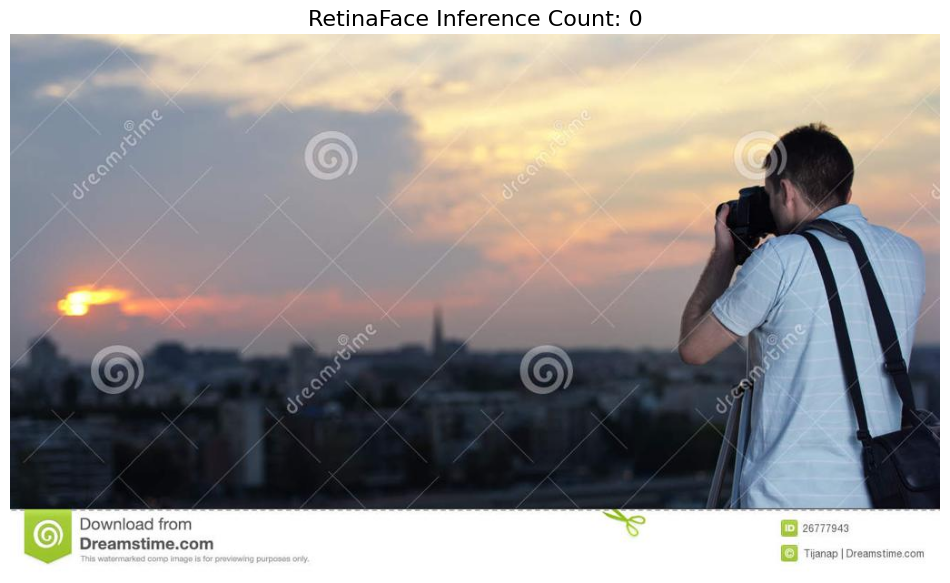

In [10]:
import cv2
import matplotlib.pyplot as plt
from retinaface import RetinaFace

def count_and_plot_retinaface(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Error: Target validation image not found at {image_path}")
        return

    print("🔄 Running deep inference via RetinaFace...")
    faces = RetinaFace.detect_faces(image_path)
    
    # Check return type to count detected faces safely
    if isinstance(faces, dict):
        num_faces = len(faces)
    else:
        num_faces = 0

    print(f"=========================================")
    print(f"📊 RetinaFace Output: {num_faces} faces identified.")
    print(f"=========================================")

    # Prepare image for bounding boxes plotting
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if num_faces > 0:
        for key, face_metadata in faces.items():
            bbox = face_metadata["facial_area"]
            # Draw highly visible green bounding boxes around faces
            cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)

    # Plot results
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title(f"RetinaFace Inference Count: {num_faces}", fontsize=16)
    plt.axis("off")
    plt.show()

# Run a test verification using one of the extracted validation files
val_images = [os.path.join(YOLO_VAL_IMG_DIR, f) for f in os.listdir(YOLO_VAL_IMG_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
if val_images:
    sample_target = val_images[0]
    count_and_plot_retinaface(sample_target)
else:
    print("⚠️ No processing images found in your validation cache to preview.")

## Vite Testing through UI

In [13]:
import io
import os
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# 1. Automatically locate your 70-epoch trained face detection weights
yolo_weights_path = "/kaggle/working/runs/face_detection/weights/best.pt"

# Initialize widget layouts
uploader = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
output_window = widgets.Output()

# 2. Interactive execution logic
def process_face_detection(change):
    with output_window:
        clear_output()
        if not uploader.value:
            return
            
        print("⚡ Image received successfully! Running your trained Face Detector...")
        
        # Verify the weights exist before loading
        if not os.path.exists(yolo_weights_path):
            print(f"❌ Error: Could not find your trained weights at: {yolo_weights_path}")
            print("👉 Check your right-hand sidebar 'Output' folder to see where your weights are saved.")
            return
            
        try:
            # Load the model inside the widget scope
            trained_model = YOLO(yolo_weights_path)
            
            # Parse the binary upload data stream from your PC
            file_info = uploader.value[0]
            image_bytes = file_info['content']
            img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            
            # Run inference predictions
            results = trained_model.predict(source=img, conf=0.25)
            
            # 3. Render and display the results visually
            for r in results:
                im_array = r.plot()  # Draws the bounding boxes around detected faces
                annotated_img = Image.fromarray(im_array[..., ::-1])  # Convert BGR back to RGB
                
                plt.figure(figsize=(10, 8))
                plt.imshow(annotated_img)
                plt.axis("off")
                plt.title("YOLOv8 Trained Face Detection Output", fontsize=14, fontweight='bold')
                plt.show()
                
        except Exception as e:
            print(f"❌ Runtime Processing Error: {e}")

# Register the upload trigger event listener
uploader.observe(process_face_detection, names='value')

print("👇 Click the button below to pick a photo from your PC to test your trained face detector:")
display(uploader, output_window)

👇 Click the button below to pick a photo from your PC to test your trained face detector:


FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

Output()